In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/README.md
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/requirements.txt
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/configs/config.yaml
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/train.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/evaluate.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/explain.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/losses.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/model.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/derive_risk_labels.py
/kaggle/input/datasets/kiruth23/deep-learning/dr_multitask/src/dataset.py
/kaggle/input/datasets/mariaherrerot/aptos2019/valid.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/test.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/train_1.csv
/kaggle/input/datasets/mariaherrerot/aptos2019/val_images/val_images/17f6c7072f

In [2]:
import pandas as pd

APTOS_DIR = '/kaggle/input/datasets/mariaherrerot/aptos2019'
IDRID_DIR = '/kaggle/input/datasets/mariaherrerot/idrid-dataset'

train_df = pd.read_csv(f'{APTOS_DIR}/train_1.csv')
print("APTOS columns:", train_df.columns.tolist())
print(train_df.head())

idrid_df = pd.read_csv(f'{IDRID_DIR}/idrid_labels.csv')
print("\nIDRiD columns:", idrid_df.columns.tolist())
print(idrid_df.head())

APTOS columns: ['id_code', 'diagnosis']
        id_code  diagnosis
0  1ae8c165fd53          2
1  1b329a127307          1
2  1b32e1d775ea          4
3  1b3647865779          0
4  1b398c0494d1          0

IDRiD columns: ['id_code', 'diagnosis', 'Risk of macular edema ', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11']
     id_code  diagnosis  Risk of macular edema   Unnamed: 3  Unnamed: 4  \
0  IDRiD_001          3                       2         NaN         NaN   
1  IDRiD_002          3                       2         NaN         NaN   
2  IDRiD_003          2                       2         NaN         NaN   
3  IDRiD_004          3                       2         NaN         NaN   
4  IDRiD_005          4                       0         NaN         NaN   

   Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  Unnamed: 10  \
0         NaN         NaN         NaN         NaN         NaN          NaN

In [3]:
# Clean up IDRiD - drop the empty "Unnamed" columns
idrid_df = idrid_df[['id_code', 'diagnosis', 'Risk of macular edema ']].copy()
idrid_df.columns = ['id_code', 'diagnosis', 'dme_grade']

print(idrid_df.head())
print("\nDME grade distribution:")
print(idrid_df['dme_grade'].value_counts())
print("\nDR stage distribution (IDRiD):")
print(idrid_df['diagnosis'].value_counts())

     id_code  diagnosis  dme_grade
0  IDRiD_001          3          2
1  IDRiD_002          3          2
2  IDRiD_003          2          2
3  IDRiD_004          3          2
4  IDRiD_005          4          0

DME grade distribution:
dme_grade
2    239
0    168
1     48
Name: count, dtype: int64

DR stage distribution (IDRiD):
diagnosis
2    156
0    129
3     84
4     64
1     22
Name: count, dtype: int64


In [4]:
# Strip whitespace from column names to avoid hidden mismatch issues
idrid_df.columns = [c.strip() for c in idrid_df.columns]
print(idrid_df.columns.tolist())

['id_code', 'diagnosis', 'dme_grade']


In [5]:
print(idrid_df.head())
print("\nDME grade distribution:")
print(idrid_df['dme_grade'].value_counts())
print("\nDR stage distribution (IDRiD):")
print(idrid_df['diagnosis'].value_counts())

     id_code  diagnosis  dme_grade
0  IDRiD_001          3          2
1  IDRiD_002          3          2
2  IDRiD_003          2          2
3  IDRiD_004          3          2
4  IDRiD_005          4          0

DME grade distribution:
dme_grade
2    239
0    168
1     48
Name: count, dtype: int64

DR stage distribution (IDRiD):
diagnosis
2    156
0    129
3     84
4     64
1     22
Name: count, dtype: int64


In [6]:
# Build blindness risk label
# IDRiD: high risk if DME grade is 2 (clinically significant edema) OR DR stage is severe/proliferative
idrid_df['risk_label'] = ((idrid_df['dme_grade'] == 2) | (idrid_df['diagnosis'] >= 3)).astype(int)
idrid_df['source'] = 'idrid'

# APTOS: no DME data, so risk based on DR stage only
train_df['risk_label'] = (train_df['diagnosis'] >= 3).astype(int)
train_df['source'] = 'aptos'

# Combine into one unified table
combined_df = pd.concat([
    train_df[['id_code', 'diagnosis', 'risk_label', 'source']],
    idrid_df[['id_code', 'diagnosis', 'risk_label', 'source']]
], ignore_index=True)

print("Combined dataset shape:", combined_df.shape)
print("\nRisk label distribution:")
print(combined_df['risk_label'].value_counts())
print("\nBy source:")
print(combined_df.groupby('source')['risk_label'].value_counts())
print("\n", combined_df.head())
print("\n", combined_df.tail())

Combined dataset shape: (3385, 4)

Risk label distribution:
risk_label
0    2733
1     652
Name: count, dtype: int64

By source:
source  risk_label
aptos   0             2542
        1              388
idrid   1              264
        0              191
Name: count, dtype: int64

         id_code  diagnosis  risk_label source
0  1ae8c165fd53          2           0  aptos
1  1b329a127307          1           0  aptos
2  1b32e1d775ea          4           1  aptos
3  1b3647865779          0           0  aptos
4  1b398c0494d1          0           0  aptos

             id_code  diagnosis  risk_label source
3380  IDRiD_096test          0           0  idrid
3381  IDRiD_100test          2           0  idrid
3382  IDRiD_101test          1           0  idrid
3383  IDRiD_102test          2           1  idrid
3384  IDRiD_103test          0           0  idrid


aptos | 1ae8c165fd53 | path exists: True | path: /kaggle/input/datasets/mariaherrerot/aptos2019/train_images/train_images/1ae8c165fd53.png
idrid | IDRiD_001 | path exists: True | path: /kaggle/input/datasets/mariaherrerot/idrid-dataset/Imagenes/Imagenes/IDRiD_001.jpg


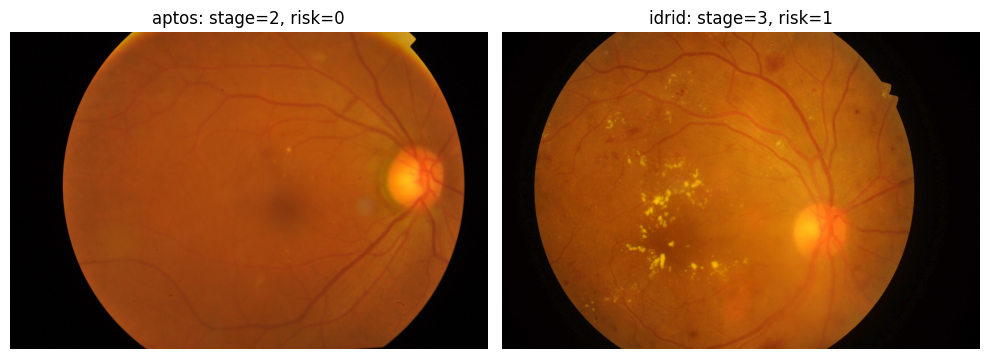

In [7]:
import cv2
import matplotlib.pyplot as plt
import os

def get_image_path(row):
    if row['source'] == 'aptos':
        return f"{APTOS_DIR}/train_images/train_images/{row['id_code']}.png"
    else:  # idrid
        return f"{IDRID_DIR}/Imagenes/Imagenes/{row['id_code']}.jpg"

# Test loading one image from each source
test_aptos = combined_df[combined_df['source'] == 'aptos'].iloc[0]
test_idrid = combined_df[combined_df['source'] == 'idrid'].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, row in zip(axes, [test_aptos, test_idrid]):
    path = get_image_path(row)
    exists = os.path.exists(path)
    print(f"{row['source']} | {row['id_code']} | path exists: {exists} | path: {path}")
    if exists:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"{row['source']}: stage={row['diagnosis']}, risk={row['risk_label']}")
        ax.axis('off')

plt.tight_layout()
plt.show()

In [8]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = 224  # good balance of detail vs speed for this dataset size

def load_and_preprocess(id_code, source):
    id_code = id_code.numpy().decode()
    source = source.numpy().decode()

    if source == 'aptos':
        path = f"{APTOS_DIR}/train_images/train_images/{id_code}.png"
    else:
        path = f"{IDRID_DIR}/Imagenes/Imagenes/{id_code}.jpg"

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # CLAHE - standard contrast enhancement for fundus images
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

    return img.astype(np.float32) / 255.0

def tf_load_wrapper(id_code, source, stage, risk):
    img = tf.py_function(load_and_preprocess, [id_code, source], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, {'stage_output': stage, 'risk_output': risk}

def make_dataset(df, batch_size=16, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df['id_code'].values,
        df['source'].values,
        df['diagnosis'].values,
        df['risk_label'].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(tf_load_wrapper, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Split into train/val, stratified by DR stage to keep class balance
train_split, val_split = train_test_split(
    combined_df, test_size=0.2, stratify=combined_df['diagnosis'], random_state=42
)

train_ds = make_dataset(train_split, batch_size=16, shuffle=True)
val_ds = make_dataset(val_split, batch_size=16, shuffle=False)

print(f"Train: {len(train_split)} images | Val: {len(val_split)} images")

# Quick sanity check - pull one batch and check shapes
for imgs, labels in train_ds.take(1):
    print("Image batch shape:", imgs.shape)
    print("Stage labels:", labels['stage_output'].numpy())
    print("Risk labels:", labels['risk_output'].numpy())

I0000 00:00:1783926949.132231      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783926949.135426      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Train: 2708 images | Val: 677 images
Image batch shape: (16, 224, 224, 3)
Stage labels: [3 0 0 0 2 2 4 0 0 1 0 0 2 2 2 0]
Risk labels: [1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [9]:
print("GPUs available:", tf.config.list_physical_devices('GPU'))

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [10]:
from tensorflow.keras import layers, models

def channel_attention(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def build_model(img_size=224, num_stages=5):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='fundus_image')

    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False, weights='imagenet', input_tensor=inputs
    )
    # Freeze early layers, fine-tune the last ~30 (standard transfer learning)
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    feats = backbone.output
    feats = layers.Conv2D(128, 1, activation='relu', name='last_conv_features')(feats)
    att_feats = channel_attention(feats)
    pooled = layers.GlobalAveragePooling2D()(att_feats)

    s = layers.Dense(128, activation='relu')(pooled)
    s = layers.Dropout(0.4)(s)
    stage_out = layers.Dense(num_stages, activation='softmax', name='stage_output')(s)

    r = layers.Dense(128, activation='relu')(pooled)
    r = layers.Dropout(0.4)(r)
    risk_out = layers.Dense(1, activation='sigmoid', name='risk_output')(r)

    return models.Model(inputs=inputs, outputs=[stage_out, risk_out], name='DR_MultiTask_EfficientNet')

model = build_model(img_size=IMG_SIZE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={'stage_output': 'sparse_categorical_crossentropy', 'risk_output': 'binary_crossentropy'},
    metrics={'stage_output': 'accuracy', 'risk_output': tf.keras.metrics.AUC(name='auc')}
)
model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DR_MultiTask_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fundus_image        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ fundus_image[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,018,309 (42.03 MB)

 Trainable params: 3,788,944 (14.45 MB)

 Non-trainable params: 7,229,365 (27.58 MB)

In [11]:
from tensorflow.keras import layers, models

def channel_attention(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def build_model(img_size=224, num_stages=5):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='fundus_image')

    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False, weights='imagenet', input_tensor=inputs
    )
    # Freeze early layers, fine-tune the last ~30 (standard transfer learning)
    for layer in backbone.layers[:-30]:
        layer.trainable = False

    feats = backbone.output
    feats = layers.Conv2D(128, 1, activation='relu', name='last_conv_features')(feats)
    att_feats = channel_attention(feats)
    pooled = layers.GlobalAveragePooling2D()(att_feats)

    s = layers.Dense(128, activation='relu')(pooled)
    s = layers.Dropout(0.4)(s)
    stage_out = layers.Dense(num_stages, activation='softmax', name='stage_output')(s)

    r = layers.Dense(128, activation='relu')(pooled)
    r = layers.Dropout(0.4)(r)
    risk_out = layers.Dense(1, activation='sigmoid', name='risk_output')(r)

    return models.Model(inputs=inputs, outputs=[stage_out, risk_out], name='DR_MultiTask_EfficientNet')

model = build_model(img_size=IMG_SIZE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={'stage_output': 'sparse_categorical_crossentropy', 'risk_output': 'binary_crossentropy'},
    metrics={'stage_output': 'accuracy', 'risk_output': tf.keras.metrics.AUC(name='auc')}
)
model.summary()


Model: "DR_MultiTask_EfficientNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fundus_image        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ fundus_image[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,080 │ stem_conv_pad[0]… │
│                     │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        160 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        360 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        160 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 40)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 40)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 10)  │        410 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 40)  │        440 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 40)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        960 │ block1a_se_excit

 Total params: 11,018,309 (42.03 MB)

 Trainable params: 3,788,944 (14.45 MB)

 Non-trainable params: 7,229,365 (27.58 MB)

In [12]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras', monitor='val_loss', save_best_only=True
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20


2026-07-13 07:16:31.207198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:16:31.348941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:16:31.684042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:16:31.832226: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:16:31.978519: E external/local_xla/xla/stream_

169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - loss: 1.9652 - risk_output_auc: 0.5106 - risk_output_loss: 0.5398 - stage_output_accuracy: 0.3972 - stage_output_loss: 1.4254

2026-07-13 07:18:31.386182: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:18:31.523562: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:18:31.835538: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:18:31.982246: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:18:32.788927: E external/local_xla/xla/stream_

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - loss: 1.9647 - risk_output_auc: 0.5106 - risk_output_loss: 0.5396 - stage_output_accuracy: 0.3974 - stage_output_loss: 1.4251

2026-07-13 07:19:28.271365: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:19:28.408805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:19:28.725053: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:19:28.871696: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-13 07:19:29.642289: E external/local_xla/xla/stream_

170/170 ━━━━━━━━━━━━━━━━━━━━ 220s 985ms/step - loss: 1.8827 - risk_output_auc: 0.5119 - risk_output_loss: 0.5046 - stage_output_accuracy: 0.4405 - stage_output_loss: 1.3774 - val_loss: 1.9163 - val_risk_output_auc: 0.5854 - val_risk_output_loss: 0.5294 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3940 - learning_rate: 1.0000e-04
Epoch 2/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 107s 631ms/step - loss: 1.8395 - risk_output_auc: 0.5328 - risk_output_loss: 0.4964 - stage_output_accuracy: 0.4601 - stage_output_loss: 1.3507 - val_loss: 1.7982 - val_risk_output_auc: 0.5959 - val_risk_output_loss: 0.5015 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3083 - learning_rate: 1.0000e-04
Epoch 3/20
170/170 ━━━━━━━━━━━━━━━━━━━━ 107s 632ms/step - loss: 1.8218 - risk_output_auc: 0.5160 - risk_output_loss: 0.4961 - stage_output_accuracy: 0.4786 - stage_output_loss: 1.3227 - val_loss: 1.7443 - val_risk_output_auc: 0.6121 - val_risk_output_loss: 0.4981 - val_stage_output_accuracy

In [13]:
import numpy as np
from sklearn.metrics import cohen_kappa_score, roc_auc_score

stage_preds, risk_preds, stage_true, risk_true = [], [], [], []

for imgs, labels in val_ds:
    sp, rp = model.predict(imgs, verbose=0)
    stage_preds.extend(np.argmax(sp, axis=1))
    risk_preds.extend(rp.flatten())
    stage_true.extend(labels['stage_output'].numpy())
    risk_true.extend(labels['risk_output'].numpy())

kappa = cohen_kappa_score(stage_true, stage_preds, weights='quadratic')
auc = roc_auc_score(risk_true, risk_preds)
print(f"Final QWK (DR stage): {kappa:.3f}")
print(f"Final AUC (blindness risk): {auc:.3f}")

Final QWK (DR stage): 0.593
Final AUC (blindness risk): 0.798


In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

# --- Class weights to handle imbalance ---
stage_weights = compute_class_weight(
    'balanced', classes=np.unique(combined_df['diagnosis']), y=combined_df['diagnosis']
)
stage_weight_dict = dict(enumerate(stage_weights))
print("Stage class weights:", stage_weight_dict)

risk_weights = compute_class_weight(
    'balanced', classes=np.unique(combined_df['risk_label']), y=combined_df['risk_label']
)
risk_weight_dict = dict(enumerate(risk_weights))
print("Risk class weights:", risk_weight_dict)

# --- Rebuild model with more trainable layers + lower LR ---
def channel_attention(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def build_model(img_size=224, num_stages=5):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='fundus_image')
    backbone = tf.keras.applications.EfficientNetB3(
        include_top=False, weights='imagenet', input_tensor=inputs
    )
    # unfreeze more layers this time (was -30, now -60)
    for layer in backbone.layers[:-60]:
        layer.trainable = False

    feats = backbone.output
    feats = layers.Conv2D(128, 1, activation='relu', name='last_conv_features')(feats)
    att_feats = channel_attention(feats)
    pooled = layers.GlobalAveragePooling2D()(att_feats)

    s = layers.Dense(128, activation='relu')(pooled)
    s = layers.Dropout(0.4)(s)
    stage_out = layers.Dense(num_stages, activation='softmax', name='stage_output')(s)

    r = layers.Dense(128, activation='relu')(pooled)
    r = layers.Dropout(0.4)(r)
    risk_out = layers.Dense(1, activation='sigmoid', name='risk_output')(r)

    return models.Model(inputs=inputs, outputs=[stage_out, risk_out], name='DR_MultiTask_v2')

model = build_model(img_size=IMG_SIZE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),  # lower LR
    loss={'stage_output': 'sparse_categorical_crossentropy', 'risk_output': 'binary_crossentropy'},
    metrics={'stage_output': 'accuracy', 'risk_output': tf.keras.metrics.AUC(name='auc')}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model_v2.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

# Note: Keras multi-output class_weight needs per-output dicts under one dict
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks,
    class_weight=None  # see note below
)

Stage class weights: {0: np.float64(0.4331413947536788), 1: np.float64(2.1024844720496896), 2: np.float64(0.7022821576763485), 3: np.float64(2.8445378151260505), 4: np.float64(2.271812080536913)}
Risk class weights: {0: np.float64(0.619282839370655), 1: np.float64(2.5958588957055215)}
Epoch 1/40
170/170 ━━━━━━━━━━━━━━━━━━━━ 195s 867ms/step - loss: 1.9619 - risk_output_auc: 0.5190 - risk_output_loss: 0.5499 - stage_output_accuracy: 0.4269 - stage_output_loss: 1.4094 - val_loss: 1.9034 - val_risk_output_auc: 0.5388 - val_risk_output_loss: 0.5241 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3870 - learning_rate: 5.0000e-05
Epoch 2/40
170/170 ━━━━━━━━━━━━━━━━━━━━ 109s 642ms/step - loss: 1.8579 - risk_output_auc: 0.5029 - risk_output_loss: 0.4989 - stage_output_accuracy: 0.4509 - stage_output_loss: 1.3581 - val_loss: 1.8261 - val_risk_output_auc: 0.6017 - val_risk_output_loss: 0.5019 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3348 - learning_rate: 5.000

In [15]:

import pickle
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight

# --- Compute class weights ---
stage_weights = compute_class_weight('balanced', classes=np.unique(combined_df['diagnosis']), y=combined_df['diagnosis'])
stage_weight_dict = dict(enumerate(stage_weights))
risk_weights = compute_class_weight('balanced', classes=np.unique(combined_df['risk_label']), y=combined_df['risk_label'])
risk_weight_dict = dict(enumerate(risk_weights))
print("Stage weights:", stage_weight_dict)
print("Risk weights:", risk_weight_dict)

def channel_attention(x, reduction=8):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // reduction, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def build_model(img_size=224, num_stages=5):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='fundus_image')
    backbone = tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)

    # Unfreeze last 40 layers, BUT keep ALL BatchNorm layers frozen everywhere
    for layer in backbone.layers[:-40]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False   # <-- the critical fix

    feats = backbone.output
    feats = layers.Conv2D(128, 1, activation='relu', name='last_conv_features')(feats)
    att_feats = channel_attention(feats)
    pooled = layers.GlobalAveragePooling2D()(att_feats)

    s = layers.Dense(128, activation='relu')(pooled)
    s = layers.Dropout(0.4)(s)
    stage_out = layers.Dense(num_stages, activation='softmax', name='stage_output')(s)

    r = layers.Dense(128, activation='relu')(pooled)
    r = layers.Dropout(0.4)(r)
    risk_out = layers.Dense(1, activation='sigmoid', name='risk_output')(r)

    return models.Model(inputs=inputs, outputs=[stage_out, risk_out], name='DR_MultiTask')

model = build_model(img_size=IMG_SIZE)

trainable_count = sum([1 for l in model.layers if l.trainable])
print(f"Trainable layers: {trainable_count} / {len(model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={'stage_output': 'sparse_categorical_crossentropy', 'risk_output': 'binary_crossentropy'},
    metrics={'stage_output': 'accuracy', 'risk_output': tf.keras.metrics.AUC(name='auc')}
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_stage_output_accuracy', mode='max', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=30, callbacks=callbacks)

with open('history.pkl', 'wb') as f:
    pickle.dump(history.history, f)
print("Training complete. History saved.")

Stage weights: {0: np.float64(0.4331413947536788), 1: np.float64(2.1024844720496896), 2: np.float64(0.7022821576763485), 3: np.float64(2.8445378151260505), 4: np.float64(2.271812080536913)}
Risk weights: {0: np.float64(0.619282839370655), 1: np.float64(2.5958588957055215)}
Trainable layers: 45 / 398
Epoch 1/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 183s 845ms/step - loss: 1.8957 - risk_output_auc: 0.4974 - risk_output_loss: 0.5058 - stage_output_accuracy: 0.4350 - stage_output_loss: 1.3916 - val_loss: 1.8412 - val_risk_output_auc: 0.5605 - val_risk_output_loss: 0.5039 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3503 - learning_rate: 1.0000e-04
Epoch 2/30
170/170 ━━━━━━━━━━━━━━━━━━━━ 107s 630ms/step - loss: 1.8609 - risk_output_auc: 0.4893 - risk_output_loss: 0.4991 - stage_output_accuracy: 0.4631 - stage_output_loss: 1.3614 - val_loss: 1.8559 - val_risk_output_auc: 0.5580 - val_risk_output_loss: 0.5094 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3566 - learn

In [16]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [17]:
import pandas as pd

APTOS_DIR = '/kaggle/input/datasets/mariaherrerot/aptos2019'
IDRID_DIR = '/kaggle/input/datasets/mariaherrerot/idrid-dataset'

train_df = pd.read_csv(f'{APTOS_DIR}/train_1.csv')
idrid_df = pd.read_csv(f'{IDRID_DIR}/idrid_labels.csv')
idrid_df.columns = [c.strip() for c in idrid_df.columns]
idrid_df = idrid_df[['id_code', 'diagnosis', 'Risk of macular edema']].copy()
idrid_df.columns = ['id_code', 'diagnosis', 'dme_grade']

print("APTOS:", train_df.shape)
print("IDRiD:", idrid_df.shape)

APTOS: (2930, 2)
IDRiD: (455, 3)


In [18]:
idrid_df['risk_label'] = ((idrid_df['dme_grade'] == 2) | (idrid_df['diagnosis'] >= 3)).astype(int)
idrid_df['source'] = 'idrid'

train_df['risk_label'] = (train_df['diagnosis'] >= 3).astype(int)
train_df['source'] = 'aptos'

combined_df = pd.concat([
    train_df[['id_code', 'diagnosis', 'risk_label', 'source']],
    idrid_df[['id_code', 'diagnosis', 'risk_label', 'source']]
], ignore_index=True)

print("Combined dataset:", combined_df.shape)
print(combined_df['risk_label'].value_counts())
print(combined_df['diagnosis'].value_counts())

Combined dataset: (3385, 4)
risk_label
0    2733
1     652
Name: count, dtype: int64
diagnosis
0    1563
2     964
1     322
4     298
3     238
Name: count, dtype: int64


In [19]:
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

IMG_SIZE = 224

def load_and_preprocess(image_id, img_dir):
    img = cv2.imread(f'{img_dir}/{image_id}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    img = cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)
    return img.astype(np.float32) / 255.0

def get_image_path(id_code, source):
    if source == 'aptos':
        return f'{id_code}.png', f'{APTOS_DIR}/train_images/train_images'
    else:
        return f'{id_code}.jpg', f'{IDRID_DIR}/Imagenes/Imagenes'

def tf_load_image(id_code, source, stage, risk):
    def _load(id_code, source):
        fname, img_dir = get_image_path(id_code.numpy().decode(), source.numpy().decode())
        return load_and_preprocess(fname, img_dir)
    img = tf.py_function(_load, [id_code, source], tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return img, {'stage_output': stage, 'risk_output': risk}

def make_dataset(df, batch_size=16, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df['id_code'].values, df['source'].values,
        df['diagnosis'].values, df['risk_label'].values
    ))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(df))
    ds = ds.map(tf_load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_split, val_split = train_test_split(
    combined_df, test_size=0.2, stratify=combined_df['diagnosis'], random_state=42
)
train_ds = make_dataset(train_split, batch_size=16, shuffle=True)
val_ds = make_dataset(val_split, batch_size=16, shuffle=False)

print(f"Train: {len(train_split)} | Val: {len(val_split)}")

Train: 2708 | Val: 677


In [20]:
from sklearn.metrics import cohen_kappa_score, roc_auc_score

stage_preds, risk_preds, stage_true, risk_true = [], [], [], []
for imgs, labels in val_ds:
    sp, rp = model.predict(imgs, verbose=0)
    stage_preds.extend(np.argmax(sp, axis=1))
    risk_preds.extend(rp.flatten())
    stage_true.extend(labels['stage_output'].numpy())
    risk_true.extend(labels['risk_output'].numpy())

kappa = cohen_kappa_score(stage_true, stage_preds, weights='quadratic')
auc = roc_auc_score(risk_true, risk_preds)
print(f"Final QWK (DR stage): {kappa:.3f}")
print(f"Final AUC (blindness risk): {auc:.3f}")

Final QWK (DR stage): 0.303
Final AUC (blindness risk): 0.606


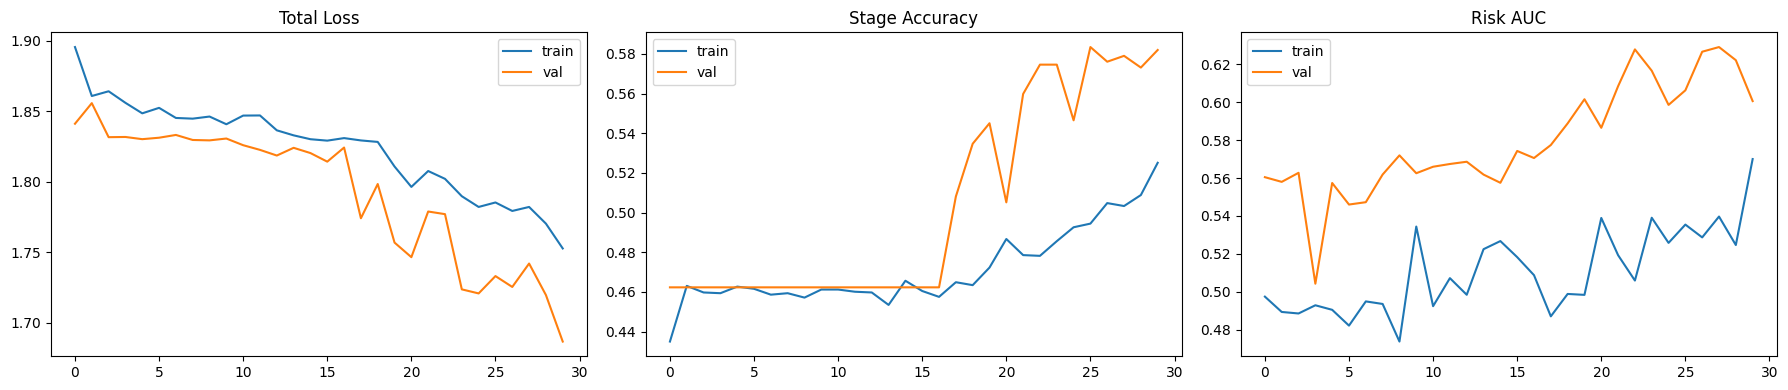

In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Total Loss'); axes[0].legend()

axes[1].plot(history.history['stage_output_accuracy'], label='train')
axes[1].plot(history.history['val_stage_output_accuracy'], label='val')
axes[1].set_title('Stage Accuracy'); axes[1].legend()

axes[2].plot(history.history['risk_output_auc'], label='train')
axes[2].plot(history.history['val_risk_output_auc'], label='val')
axes[2].set_title('Risk AUC'); axes[2].legend()
plt.tight_layout()
plt.show()

In [22]:
model.save('/kaggle/working/dr_multitask_model.keras')
print("Saved to /kaggle/working/dr_multitask_model.keras — download it from the Output tab")

Saved to /kaggle/working/dr_multitask_model.keras — download it from the Output tab


In [23]:
import numpy as np
print("Unique predicted stages:", np.unique(stage_preds, return_counts=True))
print("Unique predicted risk probabilities (first 20):", np.round(risk_preds[:20], 3))

Unique predicted stages: (array([0, 2]), array([452, 225]))
Unique predicted risk probabilities (first 20): [0.151 0.2   0.241 0.245 0.173 0.158 0.193 0.206 0.175 0.198 0.244 0.153
 0.166 0.182 0.173 0.143 0.164 0.239 0.207 0.218]


In [24]:
from tensorflow.keras import layers, models

def build_simple_model(img_size=224, num_stages=5):
    inputs = layers.Input(shape=(img_size, img_size, 3), name='fundus_image')
    backbone = tf.keras.applications.EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs, pooling='avg')

    # Freeze everything except a small trainable head - simplest possible setup
    backbone.trainable = False

    pooled = backbone.output

    s = layers.Dense(64, activation='relu')(pooled)
    stage_out = layers.Dense(num_stages, activation='softmax', name='stage_output')(s)

    r = layers.Dense(64, activation='relu')(pooled)
    risk_out = layers.Dense(1, activation='sigmoid', name='risk_output')(r)

    return models.Model(inputs=inputs, outputs=[stage_out, risk_out], name='DR_Simple_Diagnostic')

simple_model = build_simple_model(img_size=IMG_SIZE)
simple_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss={'stage_output': 'sparse_categorical_crossentropy', 'risk_output': 'binary_crossentropy'},
    metrics={'stage_output': 'accuracy', 'risk_output': tf.keras.metrics.AUC(name='auc')}
)

print("Trainable params:", sum([tf.size(w).numpy() for w in simple_model.trainable_weights]))

diag_history = simple_model.fit(train_ds, validation_data=val_ds, epochs=10)

Trainable params: 197126
Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 173s 816ms/step - loss: 1.8803 - risk_output_auc: 0.5009 - risk_output_loss: 0.5062 - stage_output_accuracy: 0.4398 - stage_output_loss: 1.3710 - val_loss: 1.8332 - val_risk_output_auc: 0.5778 - val_risk_output_loss: 0.5139 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3340
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 108s 635ms/step - loss: 1.8473 - risk_output_auc: 0.4878 - risk_output_loss: 0.5032 - stage_output_accuracy: 0.4583 - stage_output_loss: 1.3425 - val_loss: 1.8234 - val_risk_output_auc: 0.5780 - val_risk_output_loss: 0.5069 - val_stage_output_accuracy: 0.4623 - val_stage_output_loss: 1.3293
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 107s 628ms/step - loss: 1.8450 - risk_output_auc: 0.5100 - risk_output_loss: 0.4953 - stage_output_accuracy: 0.4586 - stage_output_loss: 1.3465 - val_loss: 1.8342 - val_risk_output_auc: 0.5695 - val_risk_output_loss: 0.5063 - val_stage_output_accuracy: 0.4623 - val_stage